# Linear discriminant analysis


In [1]:
import os

import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA

## Exercise 1: train LDA
1. Write the function `train_lda(X, y)` that accepts the data $\mathbf{X}\in\mathbb{R}^{N \times D}$ of $N$ examples and $D$ features and the labels $\mathbf{y}\in\mathbb{N}^N$ containing integer class labels, one for each example. The function should output the `weights` and `bias`. Note, we assume a binary classification problem.

$$J(w)=\frac{(m_2-m_1)^2}{s_1^2+s_2^2} \text{ (projected space)} = \frac{w^Ts_Bw}{w^Ts_Ww} \text{ (original space)}$$

For best projection, maximize distance, minimize within-class variance: $argmax_w \text{ } J(w)$
To argmax, differentiate by $w$, assume Linear Discriminant Analysis, solve for $\frac{dJ(w)}{dw}=0$ and $\frac{dJ(w)}{db}=0$, $w = S_W^{-1}(m_2-m_1)$, $b = - \frac{w^T(m_1+m_2)}{2}$


Total within-class covariance matrix: $S_W = \frac{1}{2}(s_1 + s_2)$ for balanced classes, otherwise $S_W= \frac{\sum N_k s_k}{N}$
Between-class covariance matrix: $S_B = (m_2-m_1)(m_2-m_1)^T$

Covariance matrix of class $C_k = S_k = \frac{\sum_{n \in C_k} (x_n-m_k)(x_n-m_k)^T}{N_k-1}$

In [2]:
from typing import Tuple

def normalize_binary_y(y) -> np.ndarray:
    return y == np.unique(y).flatten()[0]  # Whatever, whatever else -> True/False or 0/1

def train_lda(X, y) -> Tuple[np.ndarray, np.ndarray]:
    assert len(np.unique(y)) == 2, "This implementation assumes a binary classification (2 output categories)"

    y = normalize_binary_y(y)
    #mask = y == np.unique(y).flatten()[0]
    classes = [X[y == 0], X[y == 1]]

    # This could probably be further numpy-ified, but the 'c in classes' only loops
    # over 2 elements, with the heavy stuff being done by numpy
    means = [np.mean(c, axis=0) for c in classes]

    # "If you know the covariance matrix of one class, you know also the covariance matrix 
    # of every other class. This must hold, even if the classes are unbalanced." - Michael Tangermann, Jordy Thielen
    tmp = classes[0] - means[0]
    cov_mat = tmp.T @ tmp / (len(classes[0]) - 1)
    
    weights = np.linalg.inv(cov_mat) @ (means[1] - means[0])
    
    bias = - weights @ (means[0] + means[1]) / 2

    return weights, bias

## Exercise 2: apply LDA
1. Write the function `apply_lda(X, weights, bias)` to apply a trained LDA (given by `weights` and `bias`) to new data (i.e., validation/test data) $\mathbf{X}\in\mathbb{R}^{N \times D}$. The output should be predicted class labels $\mathbf{\hat{y}}\in\mathbb{N}^N$ containing integer class labels, one for each example.

In [3]:
def apply_lda(X, weights, bias) -> np.ndarray:
    pred = weights @ X.T + bias
    
    return np.signbit(pred)  # np.sign outputs -1/0/1, np.signbit outputs True/False ergo 0/1

## Exercise 3: classify the Iris dataset
Now it is time to test your implementation. For this we use the well-known Iris dataset. We will restrict the dataset to only two classes.

1. Train and apply your LDA and compute the classification accuracy.
1. Train and apply the LDA from sklearn (`LDA()`), and compare its classification accuracy to yours. 

In [4]:
# Load Iris dataset
iris = datasets.load_iris()
labels = [1, 2]  # subselect 2 classes
idx = np.logical_or(iris.target == labels[0], iris.target == labels[1])
X = iris.data[idx, :]
y = iris.target[idx]

# Split data
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)
print("Number of train examples: ", X_train.shape[0])
print("Number of valid examples: ", X_valid.shape[0])
print("Number of features: ", X_train.shape[1])


Number of train examples:  80
Number of valid examples:  20
Number of features:  4


In [5]:
y = normalize_binary_y(y)

w, b = train_lda(X, y)
pred_inhouse = apply_lda(X, w, b)

clf = LDA()
clf.fit(X, y)
pred_sk = clf.predict(X)

from sklearn.metrics import confusion_matrix

#np.unique(pred_inhouse)
confusion_matrix(pred_inhouse, y)
#confusion_matrix(pred_sk, normalize_binary_y(y))

array([[47,  3],
       [ 3, 47]])

## Exercise 4: preprocess features
In the following data, LDA's linearity assumption is violated. 

1. How can the features be preprocessed to improve the performance? Hint: Think of polynomials, trigonometric functions, logarithms, exponential functions, etc.;
1. Apply your preprocessing idea to the data;
1. Visualize the preprocessed data;
1. Classify the preprocessed data using sklearn's `LDA()`. Did it improve?

Accuracy validation: 75.00


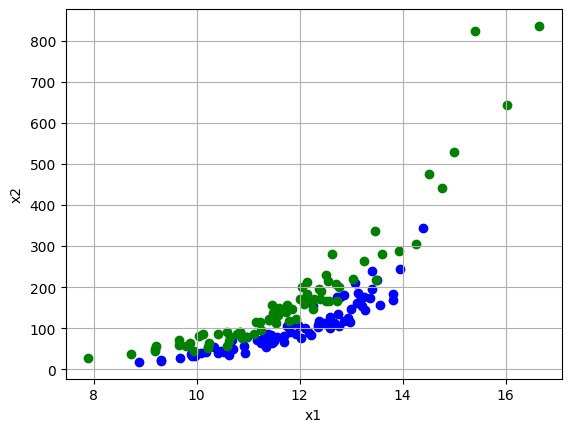

In [6]:
def make_nonlin_data(N, seed=42):
    rng = np.random.default_rng(seed)
    params = {
        0: dict(slope=0.472, intercept=-1.127, resid=0.176),
        1: dict(slope=0.425, intercept=-0.094, resid=0.160),
    }
    n0 = N // 2
    n1 = N - n0
    def sample(n, p):
        x = rng.normal(12.0, 1.6, n)
        x = np.clip(x, 7.0, 16.7)
        log_y = p["slope"] * x + p["intercept"] + rng.normal(0, p["resid"], n)
        return np.column_stack([x, np.exp(log_y)])
    X = np.vstack([sample(n0, params[0]), sample(n1, params[1])])
    labels = np.concatenate([np.zeros(n0, dtype=int), np.ones(n1, dtype=int)])
    idx = rng.permutation(N)
    return X[idx], labels[idx]

# generate data
X, y = make_nonlin_data(N=200)

# split into training and validation
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

# scatter-plot data with corresponding labels
plt.figure()
plt.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1], color='b')
plt.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1], color='g')
plt.xlabel('x1')
plt.ylabel('x2')
plt.grid()

# classify un-processed data
clf = LDA()
clf.fit(X_train, y_train)
score = clf.score(X_valid, y_valid) * 100
print(f'Accuracy validation: {score:.2f}')


Accuracy validation: 90.00


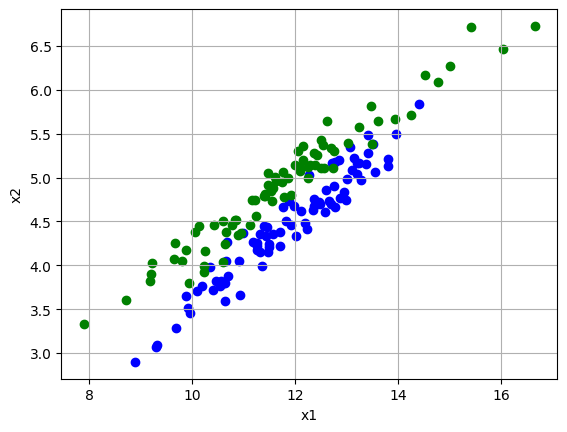

In [7]:
X, y = make_nonlin_data(N=200)

X[:, 1] = np.log(X[:, 1])  # Because x2 is exponential
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

plt.figure()
plt.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1], color='b')
plt.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1], color='g')
plt.xlabel('x1')
plt.ylabel('x2')
plt.grid()

clf = LDA()
clf.fit(X_train, y_train)
score = clf.score(X_valid, y_valid) * 100
print(f'Accuracy validation: {score:.2f}')

## Exercise 5: combine features
In the following dataset, in its original form, LDA is not able to perform classification.

1. How can the existing features be combined to get a proper dataset? 
1. Implement your feature that combines the existing features;
1. Visualize the new feature using a histogram;
1. Calculate the performance of LDA using this additional feature and see if you can improve upon the performance.

Accuracy validation: 37.50%


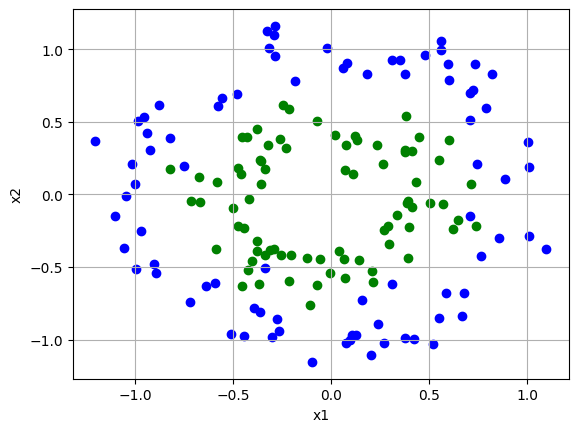

In [8]:
def make_circles_data(N, inner_radius=0.5, outer_radius=1.0, noise=0.13, seed=42):
    rng = np.random.default_rng(seed)
    n_out = N // 2
    n_in = N - n_out
    def ring(n, radius):
        theta = rng.uniform(0, 2 * np.pi, n)
        pts = np.column_stack([radius * np.cos(theta), radius * np.sin(theta)])
        return pts + rng.normal(0, noise, (n, 2))
    X = np.vstack([ring(n_out, outer_radius), ring(n_in, inner_radius)])
    y = np.concatenate([np.zeros(n_out, dtype=int), np.ones(n_in, dtype=int)])
    idx = rng.permutation(N)
    return X[idx], y[idx]

# generate data
X, y = make_circles_data(N=200)

# split into training and validation
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

# scatter-plot data with corresponding labels
plt.figure()
plt.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1] ,color='b')
plt.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1], color='g')
plt.xlabel('x1')
plt.ylabel('x2')
plt.grid()

# classify un-processed data
clf = LDA()
clf.fit(X_train, y_train)
score = clf.score(X_valid, y_valid) * 100
print('Accuracy validation: {:.2f}%'.format(score))


Accuracy validation: 100.00%
TODO: HISTOGRAM


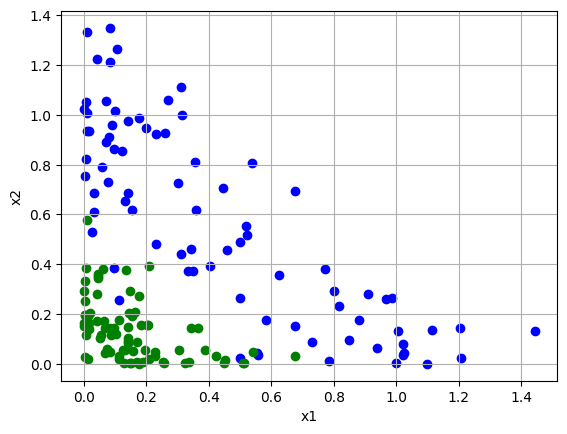

In [15]:
X, y = make_circles_data(N=200)

# NOTE: np.abs(X) has an accuracy of 97.50%, but is probably slightly faster
X = np.power(X, 2)

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

plt.figure()
plt.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1] ,color='b')
plt.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1], color='g')
plt.xlabel('x1')
plt.ylabel('x2')
plt.grid()

clf = LDA()
clf.fit(X_train, y_train)
score = clf.score(X_valid, y_valid) * 100
print('Accuracy validation: {:.2f}%'.format(score))
print("TODO: HISTOGRAM")

## Exercise 6: other LDA-like algorithms
The dataset below again violates an assumption of LDA.

1. What LDA assumption(s) are violated by the next dataset?
1. What would be an optimal decision boundary? 
1. Inspect QDA and use `QDA()` to improve classification of this dataset.

Accuracy validation: 92.50%


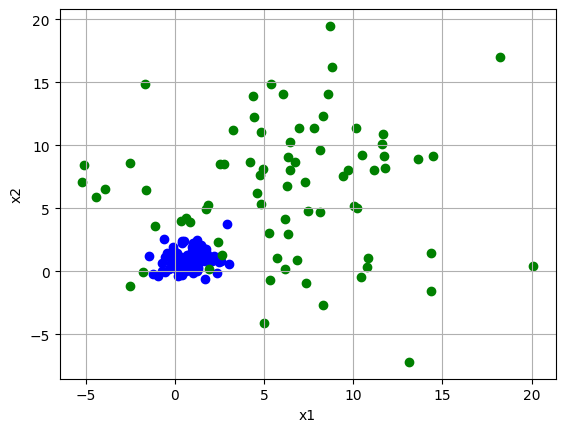

In [16]:
def make_unbalanced_data(N, seed=42):
    rng = np.random.default_rng(seed)
    n0 = N // 2
    n1 = N - n0
    c0 = rng.normal(loc=[0.8, 1.0], scale=[1.05, 0.95], size=(n0, 2))
    c1 = rng.normal(loc=[6.0, 6.8], scale=[4.85, 5.45], size=(n1, 2))
    X = np.vstack([c0, c1])
    y = np.concatenate([np.zeros(n0, dtype=int), np.ones(n1, dtype=int)])
    idx = rng.permutation(N)
    return X[idx], y[idx]

# generate data
X, y = make_unbalanced_data(N=200)

# split into training and validation
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

# scatter-plot data with corresponding labels
plt.figure()
plt.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1], color='b')
plt.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1], color='g')
plt.xlabel('x1')
plt.ylabel('x2')
plt.grid()

# classify un-processed data
clf = LDA()
clf.fit(X_train, y_train)
score = clf.score(X_valid, y_valid) * 100
print('Accuracy validation: {:.2f}%'.format(score))


1. $s_0 \neq s_1$ (different covariance)
2. 

Accuracy validation: 97.50%


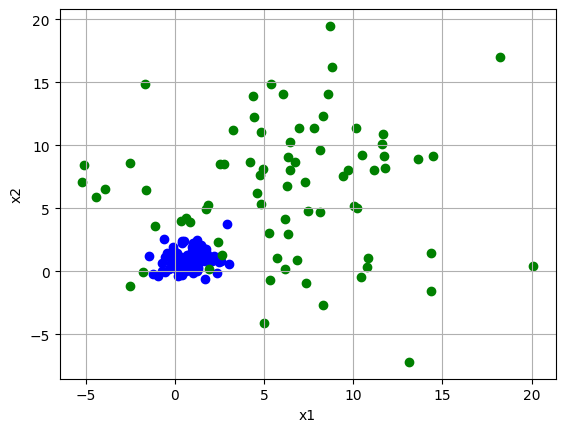

In [17]:
X, y = make_unbalanced_data(N=200)
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

plt.figure()
plt.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1], color='b')
plt.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1], color='g')
plt.xlabel('x1')
plt.ylabel('x2')
plt.grid()

clf = QDA()
clf.fit(X_train, y_train)
score = clf.score(X_valid, y_valid) * 100
print('Accuracy validation: {:.2f}%'.format(score))